In [ ]:
from google.colab import drive
drive.mount("/content/drive/")

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
# file_path = '/content/drive/MyDrive/Colab Notebooks/HW06'
# with open(file_path, 'r') as file:
#     data = file.read()
import os

os.listdir('/content/drive/MyDrive/Colab Notebooks/HW06')

['report.md', 'S06-hw-dataset-01.csv', 'artifacts', 'HW06.ipynb']

##2.3.1

In [ ]:


# Базовые библиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Модели и инструменты из scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.inspection import permutation_importance
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

#2
DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/HW06/S06-hw-dataset-01.csv"

df = pd.read_csv(DATA_PATH)
#3
#базовые статистики
df.head()
df.info()
df.describe()
#таргеты
target_col = "target"
target_distribution = df[target_col].value_counts(normalize=True)
target_distribution
#проверка пропусков
df.isna().sum()
#4
#определение x y
TARGET_COL = "target" #на всякий
ID_COL = "id"

y = df["target"]
X = df.drop(columns=["target", "id"])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 30 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             12000 non-null  int64  
 1   num01          12000 non-null  float64
 2   num02          12000 non-null  float64
 3   num03          12000 non-null  float64
 4   num04          12000 non-null  float64
 5   num05          12000 non-null  float64
 6   num06          12000 non-null  float64
 7   num07          12000 non-null  float64
 8   num08          12000 non-null  float64
 9   num09          12000 non-null  float64
 10  num10          12000 non-null  float64
 11  num11          12000 non-null  float64
 12  num12          12000 non-null  float64
 13  num13          12000 non-null  float64
 14  num14          12000 non-null  float64
 15  num15          12000 non-null  float64
 16  num16          12000 non-null  float64
 17  num17          12000 non-null  float64
 18  num18 

##2.3.2

In [ ]:

#Разделить данные на train/test
RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Фиксация случайности

np.random.seed(RANDOM_STATE)

Train shape: (9600, 28)
Test shape: (2400, 28)


Фиксированный seed нужен, чтобы разбиение и результаты модели были воспроизводимыми. Это важно для отладки и сравнения моделей.Стратификация нужна при классификации, чтобы доли классов в train и test совпадали с исходным датасетом. Без неё, особенно при дисбалансе, метрики могут быть искажены.

##2.3.3. Baseline’ы


In [ ]:
baseline_dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)

# Обучаем только на train
baseline_dummy.fit(X_train, y_train)

# Оцениваем на validation
y_pred_dummy_baseline = baseline_dummy.predict(X_test)
y_proba_dummy_baseline = baseline_dummy.predict_proba(X_test)[:, 1]

dummy_accuracy = accuracy_score(y_test, y_pred_dummy_baseline)
dummy_f1 = f1_score(y_test, y_pred_dummy_baseline)
dummy_roc_auc = roc_auc_score(y_test, y_proba_dummy_baseline)

print("DummyClassifier:")
print(f"Accuracy: {dummy_accuracy:.4f}")
print(f"F1-score: {dummy_f1:.4f}")
print(f"ROC-AUC:  {dummy_roc_auc:.4f}")
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_dummy_baseline))



DummyClassifier:
Accuracy: 0.6767
F1-score: 0.0000
ROC-AUC:  0.5000
Confusion matrix:
[[1624    0]
 [ 776    0]]


In [ ]:
#baseline основанный на логической модели
logreg_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        C=1.0,
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

logreg_pipe.fit(X_train, y_train)

y_pred_lr_baseline = logreg_pipe.predict(X_test)
y_proba_lr_baseline = logreg_pipe.predict_proba(X_test)[:, 1]

lr_accuracy = accuracy_score(y_test, y_pred_lr_baseline)
lr_f1 = f1_score(y_test, y_pred_lr_baseline)
lr_roc_auc = roc_auc_score(y_test, y_proba_lr_baseline)

print("\nLogisticRegression:")
print(f"Accuracy: {lr_accuracy:.4f}")
print(f"F1-score: {lr_f1:.4f}")
print(f"ROC-AUC:  {lr_roc_auc:.4f}")
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_lr_baseline))


LogisticRegression:
Accuracy: 0.8275
F1-score: 0.7076
ROC-AUC:  0.8747
Confusion matrix:
[[1485  139]
 [ 275  501]]


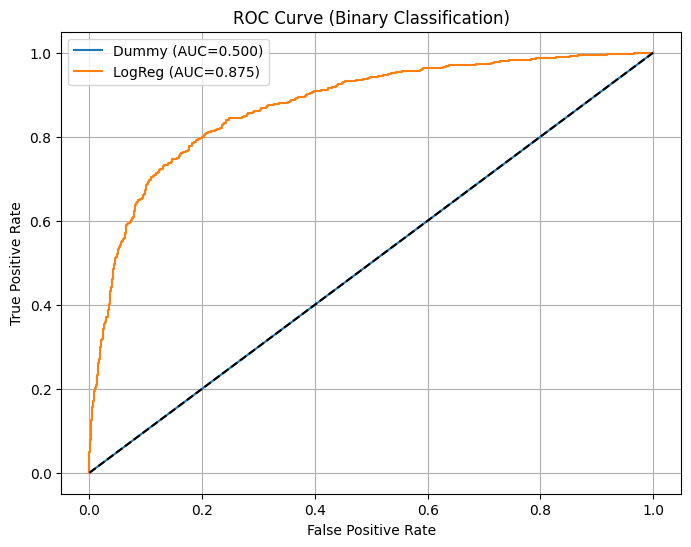

In [ ]:
fpr_dummy, tpr_dummy, _ = roc_curve(y_test, y_proba_dummy_baseline)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr_baseline)

plt.figure(figsize=(8, 6))
plt.plot(fpr_dummy, tpr_dummy, label=f"Dummy (AUC={dummy_roc_auc:.3f})")
plt.plot(fpr_lr, tpr_lr, label=f"LogReg (AUC={lr_roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Binary Classification)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
#краткая сводка
results_df = pd.DataFrame({
    "Model": ["DummyClassifier", "LogisticRegression"],
    "Accuracy": [dummy_accuracy, lr_accuracy],
    "F1-score": [dummy_f1, lr_f1],
    "ROC-AUC": [dummy_roc_auc, lr_roc_auc]
})

results_df

,Model,Accuracy,F1-score,ROC-AUC
0,DummyClassifier,0.676667,0.000000,0.500000
1,LogisticRegression,0.827500,0.707627,0.874691


## 2.3.4. Модели недели 6

## подбор гиперпараметра для дерева DecisionTreeClassifier

In [ ]:
tree_full = DecisionTreeClassifier(
    random_state=RANDOM_STATE
)
tree_full.fit(X_train, y_train)

path = tree_full.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = np.unique(path.ccp_alphas)

# Проредим, если alpha слишком много
if len(ccp_alphas) > 50:
    step = max(1, len(ccp_alphas) // 50)
    ccp_alphas = ccp_alphas[::step]

len(ccp_alphas)


60

In [ ]:
#Cost-Complexity Pruning (CCP): ccp_alpha
from sklearn.model_selection import GridSearchCV

param_grid = {
    "ccp_alpha": ccp_alphas
}

tree = DecisionTreeClassifier(
    random_state=RANDOM_STATE
)

grid = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_alpha = grid.best_params_["ccp_alpha"]
best_alpha

best_tree_DecisionTreeClassifier = grid.best_estimator_

best_tree_DecisionTreeClassifier.tree_.node_count


209

In [ ]:
#финальные матрики качества

y_pred = best_tree_DecisionTreeClassifier.predict(X_test)
y_proba_tree = best_tree_DecisionTreeClassifier.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
tree_roc_auc = roc_auc_score(y_test, y_proba_tree)

print("DecisionTree + CCP pruning (test):")
print(f"Best ccp_alpha: {best_alpha:.6f}")
print(f"Accuracy: {acc:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC-AUC:  {tree_roc_auc:.4f}")

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))


DecisionTree + CCP pruning (test):
Best ccp_alpha: 0.000556
Accuracy: 0.8821
F1-score: 0.8115
ROC-AUC:  0.9030

Confusion matrix:
[[1508  116]
 [ 167  609]]


##RandomForestClassifier

In [ ]:
path = tree_full.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = np.unique(path.ccp_alphas)

if len(ccp_alphas) > 60:
    ccp_alphas = ccp_alphas[:: max(1, len(ccp_alphas)//60)]


In [ ]:
param_grid = {
    "ccp_alpha": ccp_alphas
}

tree = DecisionTreeClassifier(random_state=RANDOM_STATE)

grid = GridSearchCV(
    tree,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",   # или accuracy / f1
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_alpha = grid.best_params_["ccp_alpha"]
best_tree = grid.best_estimator_

print("Best ccp_alpha:", best_alpha)
print("Best CV score:", grid.best_score_)


Best ccp_alpha: 0.0007909140667761359
Best CV score: 0.9071165854075783


In [ ]:
#финальные матрики качества

y_pred = best_tree.predict(X_test)
y_proba_rf = best_tree.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
rf_roc_auc = roc_auc_score(y_test, y_proba_rf)

print("DecisionTree + CCP pruning (test):")
print(f"Best ccp_alpha: {best_alpha:.6f}")
print(f"Accuracy: {acc:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC-AUC:  {rf_roc_auc:.4f}")

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))


DecisionTree + CCP pruning (test):
Best ccp_alpha: 0.000791
Accuracy: 0.8662
F1-score: 0.7870
ROC-AUC:  0.9007

Confusion matrix:
[[1486  138]
 [ 183  593]]


##Adaboosting

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

stump = DecisionTreeClassifier(
    max_depth=1,
    random_state=RANDOM_STATE
)

ada = AdaBoostClassifier(
    estimator=stump,
    random_state=RANDOM_STATE
)

param_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.05, 0.1, 0.5, 1.0],
}

grid_ada = GridSearchCV(
    ada,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_ada.fit(X_train, y_train)


GridSearchCV(cv=5,
             estimator=AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                                           random_state=42),
                                          random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1, 0.5, 1.0],
                         'n_estimators': [50, 100, 200]},
             scoring='roc_auc')

In [ ]:
print("Best AdaBoost params:", grid_ada.best_params_)
print("Best CV ROC-AUC:", grid_ada.best_score_)


Best AdaBoost params: {'learning_rate': 1.0, 'n_estimators': 200}
Best CV ROC-AUC: 0.9101293079403332


In [ ]:
best_ada = grid_ada.best_estimator_

y_pred_ada = best_ada.predict(X_test)
y_proba_ada = best_ada.predict_proba(X_test)[:, 1]

ada_accuracy = accuracy_score(y_test, y_pred_ada)
ada_f1 = f1_score(y_test, y_pred_ada)
ada_roc_auc = roc_auc_score(y_test, y_proba_ada)

print("\nAdaBoost (stumps):")
print(f"Accuracy: {ada_accuracy:.4f}")
print(f"F1-score: {ada_f1:.4f}")
print(f"ROC-AUC:  {ada_roc_auc:.4f}")
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_ada))



AdaBoost (stumps):
Accuracy: 0.8462
F1-score: 0.7432
ROC-AUC:  0.9070
Confusion matrix:
[[1497  127]
 [ 242  534]]


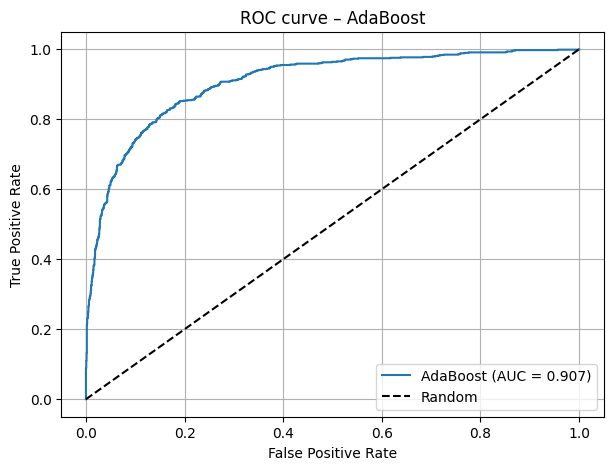

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba_ada)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AdaBoost (AUC = {ada_roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve – AdaBoost")
plt.legend()
plt.grid(True)
plt.show()


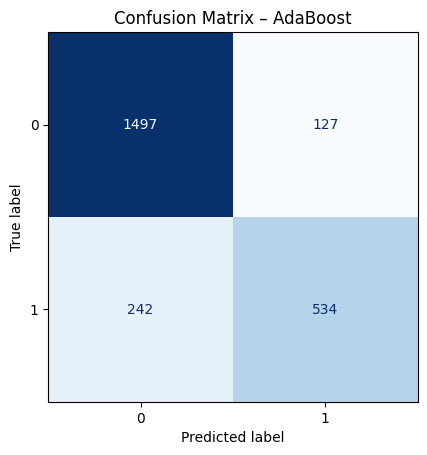

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_ada,
    cmap="Blues",
    colorbar=False
)
plt.title("Confusion Matrix – AdaBoost")
plt.show()


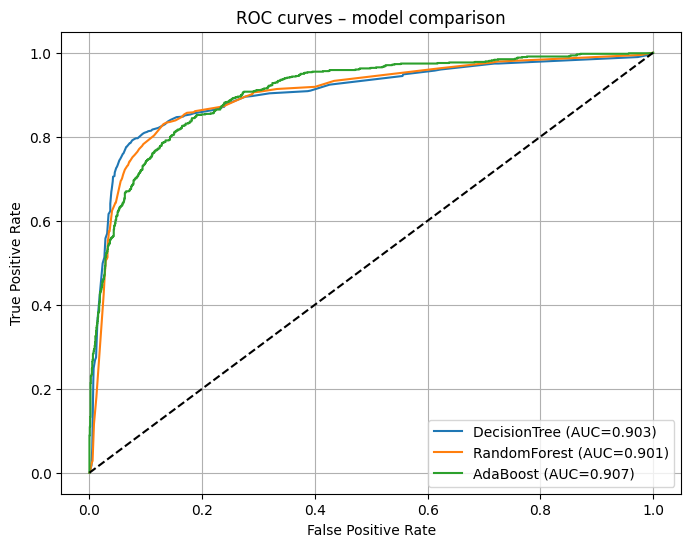

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(*roc_curve(y_test, y_proba_tree)[:2], label=f"DecisionTree (AUC={tree_roc_auc:.3f})")
plt.plot(*roc_curve(y_test, y_proba_rf)[:2], label=f"RandomForest (AUC={rf_roc_auc:.3f})")
plt.plot(*roc_curve(y_test, y_proba_ada)[:2], label=f"AdaBoost (AUC={ada_roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves – model comparison")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
results_roc_auc = [
    {
        "model": "DecisionTree (ccp_alpha=0.003)",

        "roc_auc": tree_roc_auc
    },
    {
        "model": "RandomForest",

        "roc_auc": rf_roc_auc
    },
    {
        "model": "AdaBoost",

        "roc_auc": ada_roc_auc
    }
]

        # "accuracy": tree_acc,
        # "f1": tree_f1,

                # "accuracy": rf_acc,
        # "f1": rf_f1,

        # "accuracy": ada_acc,
        # "f1": ada_f1,

In [ ]:
# Создаем словарь с моделями
trained_models = {}

# DecisionTree - у вас уже есть
trained_models['DecisionTree'] = best_tree_DecisionTreeClassifier

trained_models['RandomForest'] = best_tree

# AdaBoost - аналогично
if 'best_ada' in locals() or 'best_ada' in globals():
    trained_models['AdaBoost'] = best_ada
elif 'grid_ada' in locals() or 'grid_ada' in globals():
    trained_models['AdaBoost'] = grid_ada.best_estimator_

# Проверяем, какие модели есть в словаре
print("Доступные модели в trained_models:")
for model_name in trained_models.keys():
    print(f"- {model_name}")

Доступные модели в trained_models:
- DecisionTree
- RandomForest
- AdaBoost


In [ ]:
# Сортируем модели по ROC-AUC из списка results_roc_auc
results_sorted = sorted(results_roc_auc, key=lambda x: x["roc_auc"], reverse=True)

print("Модели, отсортированные по ROC-AUC:")
for i, result in enumerate(results_sorted, 1):
    print(f"{i}. {result['model']}: ROC-AUC = {result['roc_auc']:.4f}")

# Определяем лучшую модель
best_result = results_sorted[0]
best_model_name = best_result["model"]
print(f"\nЛучшая модель: {best_model_name} с ROC-AUC = {best_result['roc_auc']:.4f}")

# Для удобства создаем маппинг имен моделей из results_roc_auc в ключи trained_models
model_mapping = {
    "DecisionTree (ccp_alpha=0.003)": "DecisionTree",
    "RandomForest": "RandomForest",
    "AdaBoost": "AdaBoost"
}

# Получаем ключ для trained_models
if best_model_name in model_mapping:
    trained_model_key = model_mapping[best_model_name]
else:
    # Если формат имени отличается, пытаемся извлечь основное название
    for key in trained_models.keys():
        if key.lower() in best_model_name.lower():
            trained_model_key = key
            break
    else:
        trained_model_key = "DecisionTree"  # fallback

print(f"Ключ в trained_models: {trained_model_key}")

Модели, отсортированные по ROC-AUC:
1. AdaBoost: ROC-AUC = 0.9070
2. DecisionTree (ccp_alpha=0.003): ROC-AUC = 0.9030
3. RandomForest: ROC-AUC = 0.9007

Лучшая модель: AdaBoost с ROC-AUC = 0.9070
Ключ в trained_models: AdaBoost


Выполняем Permutation Importance для модели: AdaBoost
Ключ в trained_models: AdaBoost
ROC-AUC этой модели: 0.9070
Используем метрику: roc_auc


NameError: name 'feature_names' is not defined

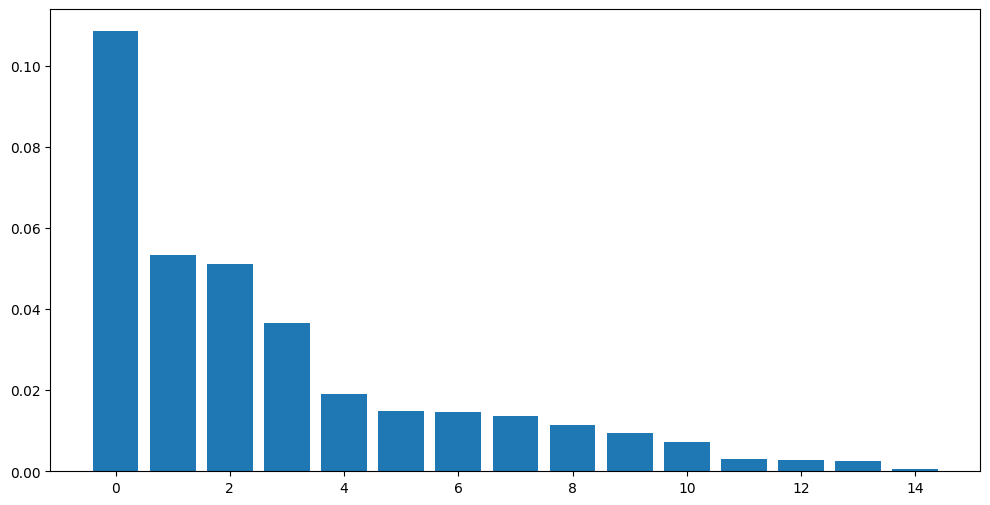

In [ ]:
# Получаем лучшую модель из словаря trained_models
best_model_for_perm = trained_models[trained_model_key]

print(f"Выполняем Permutation Importance для модели: {best_model_name}")
print(f"Ключ в trained_models: {trained_model_key}")
print(f"ROC-AUC этой модели: {best_result['roc_auc']:.4f}")

# Определяем метрику для оценки (используем ROC-AUC, так как модель поддерживает predict_proba)
scoring = "roc_auc" if hasattr(best_model_for_perm, "predict_proba") else "accuracy"
print(f"Используем метрику: {scoring}")

# Выполняем Permutation Importance
perm = permutation_importance(
    best_model_for_perm,
    X_test,
    y_test,
    n_repeats=8,  # количество повторений перемешивания
    random_state=RANDOM_STATE,
    scoring=scoring,
    n_jobs=-1  # используем все ядра процессора для ускорения
)

# Получаем важность признаков
imp = perm.importances_mean
sorted_idx = np.argsort(imp)[::-1]  # сортируем по убыванию важности

# Визуализация топ-15 признаков
top_n = 15
top_idx = sorted_idx[:top_n]

plt.figure(figsize=(12, 6))

# Создаем график
bars = plt.bar(range(top_n), imp[top_idx])
plt.xticks(range(top_n), [feature_names[i] for i in top_idx], rotation=45, ha='right')
plt.xlabel("Признаки")
plt.ylabel(f"Среднее снижение {scoring}")
plt.title(f"Permutation Importance для {best_model_name}\n(Топ-{top_n} признаков, n_repeats=8)")
plt.grid(axis='y', alpha=0.3)

# Добавляем значения на график
for bar, value in zip(bars, imp[top_idx]):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.001,
             f'{value:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Альтернативная визуализация с горизонтальными барами (лучше читаемость длинных названий)
plt.figure(figsize=(12, 8))
bars_h = plt.barh(range(top_n), imp[top_idx][::-1])
plt.yticks(range(top_n), [feature_names[i] for i in top_idx[::-1]])
plt.xlabel(f"Среднее снижение {scoring}")
plt.title(f"Permutation Importance для {best_model_name}\n(Топ-{top_n} признаков, n_repeats=8)")
plt.grid(axis='x', alpha=0.3)

# Добавляем значения на горизонтальные бары
for i, (bar, value) in enumerate(zip(bars_h, imp[top_idx][::-1])):
    plt.text(value + 0.001, bar.get_y() + bar.get_height()/2,
             f'{value:.4f}', va='center', ha='left', fontsize=9)

plt.tight_layout()
plt.show()

# Выводим таблицу с результатами
print(f"\n{'='*80}")
print(f"РЕЗУЛЬТАТЫ PERMUTATION IMPORTANCE ДЛЯ: {best_model_name}")
print(f"{'='*80}")

print(f"\nТоп-{top_n} наиболее важных признаков:")
print(f"{'№':<3} {'Признак':<35} {'Важность':<10} {'Станд. отклонение':<15}")
print("-"*70)

for i, idx in enumerate(top_idx, 1):
    print(f"{i:<3} {feature_names[idx]:<35} {imp[idx]:<10.4f} {perm.importances_std[idx]:<15.4f}")

# Дополнительный анализ: сравниваем важность признаков для всех моделей
print(f"\n{'='*80}")
print("СРАВНЕНИЕ ВАЖНОСТИ ПРИЗНАКОВ ДЛЯ РАЗНЫХ МОДЕЛЕЙ")
print(f"{'='*80}")

# Создаем DataFrame для сравнения
all_importances = pd.DataFrame(index=feature_names)

for model_key, model in trained_models.items():
    # Определяем метрику для каждой модели
    model_scoring = "roc_auc" if hasattr(model, "predict_proba") else "accuracy"

    # Вычисляем permutation importance (меньше повторений для скорости)
    perm_model = permutation_importance(
        model, X_test, y_test,
        n_repeats=5,  # меньше повторений для ускорения
        random_state=RANDOM_STATE,
        scoring=model_scoring,
        n_jobs=-1
    )

    all_importances[model_key] = perm_model.importances_mean

# Сортируем по важности в лучшей модели
all_importances_sorted = all_importances.sort_values(by=trained_model_key, ascending=False)

print("\nТоп-10 признаков по важности в лучшей модели:")
print(all_importances_sorted.head(10))

# Визуализация сравнения для топ-10 признаков лучшей модели
top_features = all_importances_sorted.head(10).index

plt.figure(figsize=(14, 8))
all_importances.loc[top_features].plot(kind='barh', figsize=(14, 8))
plt.xlabel('Важность признака (среднее снижение метрики)')
plt.title(f'Сравнение важности признаков для разных моделей\n(Топ-10 признаков по {trained_model_key})')
plt.legend(title='Модель')
plt.gca().invert_yaxis()  # самый важный вверху
plt.tight_layout()
plt.show()

# Анализ согласованности между моделями
print(f"\n{'='*80}")
print("АНАЛИЗ СОГЛАСОВАННОСТИ МОДЕЛЕЙ")
print(f"{'='*80}")

# Вычисляем корреляцию между моделями по важности признаков
correlation_matrix = all_importances.corr()
print("\nКорреляция важности признаков между моделями:")
print(correlation_matrix.round(3))

# Визуализация корреляционной матрицы
plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix, cmap='RdYlBu', vmin=-1, vmax=1)
plt.colorbar(label='Корреляция')
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)
plt.yticks(range(len(correlation_matrix.index)), correlation_matrix.index)
plt.title('Корреляция важности признаков между моделями')

# Добавляем значения корреляции на график
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.index)):
        plt.text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}',
                ha='center', va='center', color='white' if abs(correlation_matrix.iloc[i, j]) > 0.5 else 'black')

plt.tight_layout()
plt.show()

# Анализ: насколько согласованы топ-5 признаков между моделями
print("\nСравнение топ-5 признаков для каждой модели:")
for model_key in trained_models.keys():
    top_5 = all_importances[model_key].sort_values(ascending=False).head(5).index.tolist()
    print(f"\n{model_key}:")
    for i, feature in enumerate(top_5, 1):
        print(f"  {i}. {feature}")